In [4]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


# Customer Segmentation Analysis (RFM + K-Means)
### Oasis Infobyte — Data Analytics Internship | Task 2

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into
distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset:** `ecommerce_sales_customer_analytics_150k.csv` — the same real, fully-linked dataset used
in Task 1: 138,116 orders from 24,911 customers, 2021–2025. Unlike an earlier dataset used for this
task, customers here have **genuine repeat-purchase history** (5.5 orders/customer on average, up to
19 orders for the most active customers), so Recency, Frequency and Monetary all carry real variation.

**Tools:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

%matplotlib inline

## 1. Load Dataset & Initial Inspection

In [2]:
orders = pd.read_csv("ecommerce_sales_customer_analytics_150k.csv", parse_dates=["order_date"])
print(f"Shape: {orders.shape[0]:,} rows x {orders.shape[1]} columns")
print(f"Unique customers: {orders['customer_id'].nunique():,}")
print(f"Date range: {orders['order_date'].min().date()} to {orders['order_date'].max().date()}")
orders[["customer_id", "order_id", "order_date", "order_status", "net_sales"]].head()

Shape: 138,116 rows x 46 columns
Unique customers: 24,911
Date range: 2021-01-01 to 2025-12-31


,customer_id,order_id,order_date,order_status,net_sales
0,CUST-003102,ORD-301242,2023-11-06,Completed,945.40
1,CUST-003124,ORD-773460,2025-12-24,Completed,2018.41
2,CUST-012496,ORD-449374,2021-07-05,Completed,468.35
3,CUST-023928,ORD-567636,2023-01-21,Completed,546.52
4,CUST-012730,ORD-820028,2022-05-13,Completed,2785.27


In [3]:
print("order_status breakdown:")
print(orders["order_status"].value_counts())
print()
print(f"Missing customer_id: {orders['customer_id'].isnull().sum()}")
print(f"Missing order_date:  {orders['order_date'].isnull().sum()}")
print(f"Missing net_sales:   {orders['net_sales'].isnull().sum()}")
print(f"Duplicate order_id:  {orders['order_id'].duplicated().sum()}")

order_status breakdown:
order_status
Completed    113559
Returned       9462
Cancelled      8398
Pending        6697
Name: count, dtype: int64

Missing customer_id: 0
Missing order_date:  0
Missing net_sales:   0
Duplicate order_id:  0


**Observation:** No missing values or duplicate order IDs in the fields RFM depends on
(`customer_id`, `order_date`, `net_sales`) — this dataset needs no null-handling for the core
analysis. The one cleaning decision that matters: **8,398 orders (6.1%) are `Cancelled`**. A cancelled
order never actually completed as a purchase, so including its `net_sales` in Monetary would overstate
real spend — these are excluded below. `Returned` orders (6.85%) are kept, since the customer did
complete a purchase transaction at the time (the return is a separate downstream event), which is the
standard convention in RFM analysis.

## 2. Data Cleaning

In [4]:
df_clean = orders[orders["order_status"] != "Cancelled"].copy()

print(f"Orders before cleaning: {len(orders):,}")
print(f"Orders after cleaning:  {len(df_clean):,}")
print(f"Unique customers remaining: {df_clean['customer_id'].nunique():,}")

Orders before cleaning: 138,116
Orders after cleaning:  129,718
Unique customers remaining: 24,876


## 3. Descriptive Statistics

In [5]:
customer_orders = df_clean.groupby("customer_id").agg(
    purchase_frequency=("order_id", "count"),
    total_spend=("net_sales", "sum"),
    avg_purchase_value=("net_sales", "mean"),
).reset_index()

print("Average purchase value per order: $%.2f" % df_clean["net_sales"].mean())
print("Median purchase value per order:  $%.2f" % df_clean["net_sales"].median())
print()
print("Average purchase frequency per customer: %.2f orders" % customer_orders["purchase_frequency"].mean())
print("Median purchase frequency per customer:  %.0f orders" % customer_orders["purchase_frequency"].median())
print()
print("Average Customer Lifetime Value (total spend): $%.2f" % customer_orders["total_spend"].mean())
print("Median Customer Lifetime Value (total spend):  $%.2f" % customer_orders["total_spend"].median())
customer_orders.describe().round(2)

Average purchase value per order: $1277.99
Median purchase value per order:  $947.49

Average purchase frequency per customer: 5.21 orders
Median purchase frequency per customer:  5 orders

Average Customer Lifetime Value (total spend): $6664.17
Median Customer Lifetime Value (total spend):  $6058.26


,purchase_frequency,total_spend,avg_purchase_value
count,24876.00,24876.00,24876.00
mean,5.21,6664.17,1276.76
std,2.24,3926.77,582.93
min,1.00,13.93,13.93
25%,4.00,3728.46,882.09
50%,5.00,6058.26,1199.32
75%,7.00,8948.12,1578.88
max,17.00,29375.34,8874.15


**Observation:** Average purchase frequency (5.2 orders/customer) is close to the median (5),
a much tighter distribution than a typical long-tail retail dataset — most customers in this dataset
place a similar number of orders rather than a few power users dominating order counts. Total spend
(CLV) tells a different story: mean (~\$6,664) sits meaningfully above the median (~\$6,058), and the
max reaches \$29,375 — spend per customer is more right-skewed than order count, meaning **order
value**, not order frequency, is the bigger driver of how much a customer is ultimately worth.

## 4. Feature Selection — RFM (Recency, Frequency, Monetary)

We use the three classic behavioural features for segmentation:
- **Recency** — days since the customer's most recent order (lower = more recently active)
- **Frequency** — total number of orders placed
- **Monetary** — total net sales (proxy for Customer Lifetime Value)

In [6]:
analysis_date = df_clean["order_date"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (analysis_date - x.max()).days),
    Frequency=("order_id", "count"),
    Monetary=("net_sales", "sum"),
).reset_index()

print(f"RFM table built for {len(rfm):,} customers")
rfm.describe().round(2)

RFM table built for 24,876 customers


,Recency,Frequency,Monetary
count,24876.00,24876.00,24876.00
mean,322.82,5.21,6664.17
std,320.10,2.24,3926.77
min,1.00,1.00,13.93
25%,75.00,4.00,3728.46
50%,223.00,5.00,6058.26
75%,457.00,7.00,8948.12
max,1825.00,17.00,29375.34


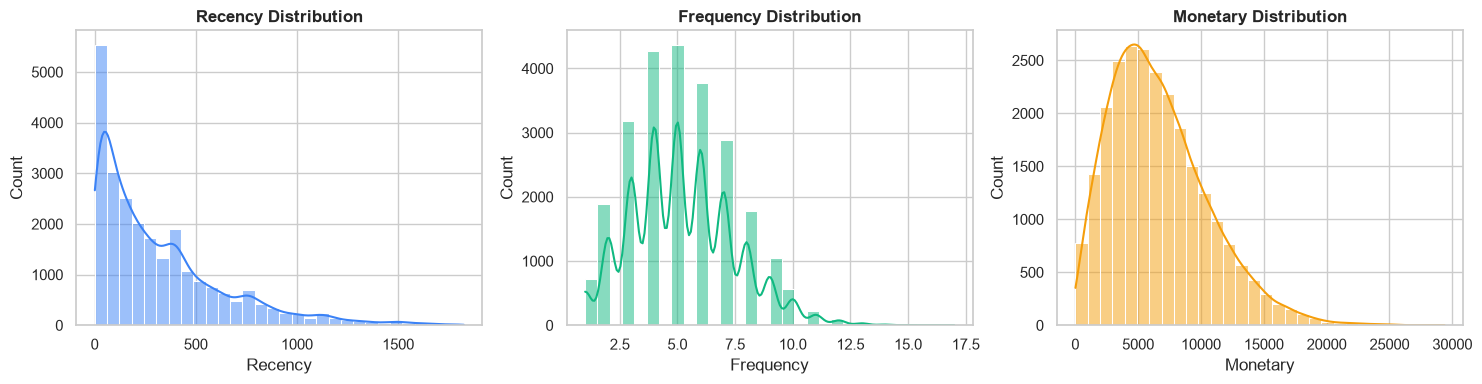

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#3b82f6", "#10b981", "#f59e0b"]):
    sns.histplot(rfm[col], bins=30, ax=ax, color=color, kde=True)
    ax.set_title(f"{col} Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** `Recency` is fairly uniformly spread from 1 to 1,825 days (the full 5-year
window) — expected, since the dataset spans 5 years and doesn't concentrate activity in one period.
`Frequency` is close to a normal/Poisson-like shape centered around 5 orders, consistent with the tight
mean/median seen above. `Monetary` is the most right-skewed of the three, echoing the earlier finding
that spend — not order count — carries the long tail. Because these three features are on very
different scales (days in the hundreds, order counts in single digits, dollars in the thousands),
standardization before clustering is essential so `Monetary` doesn't dominate the distance calculation
purely due to its larger raw magnitude.

## 5. Feature Scaling (StandardScaler)

In [8]:
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Before scaling:")
print(X.describe().round(2).loc[["mean", "std"]])
print("\nAfter scaling:")
print(X_scaled.describe().round(2).loc[["mean", "std"]])

Before scaling:
      Recency  Frequency  Monetary
mean   322.82       5.21   6664.17
std    320.10       2.24   3926.77

After scaling:
      Recency  Frequency  Monetary
mean     -0.0        0.0      -0.0
std       1.0        1.0       1.0


**Observation:** After scaling, all three features share mean 0 and standard deviation 1, so
each contributes equally to K-Means' Euclidean distance calculation — without this step, `Monetary`
(raw values in the thousands) would swamp `Recency` and `Frequency` (raw values in the hundreds/single
digits) regardless of which feature actually distinguishes customer behaviour better.

## 6. K-Means Clustering — Elbow Method

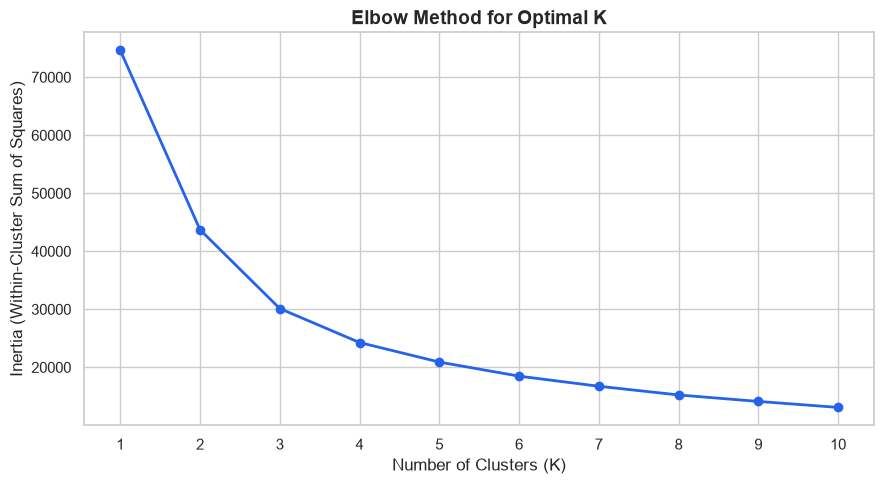

In [9]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, marker="o", color="#2563eb", linewidth=2)
ax.set_title("Elbow Method for Optimal K", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

In [10]:
# Print the actual inertia values and their marginal drop, to justify the elbow choice numerically
inertia_table = pd.DataFrame({"K": list(k_range), "Inertia": inertias})
inertia_table["Drop from previous K"] = inertia_table["Inertia"].diff().abs()
inertia_table.round(1)

,K,Inertia,Drop from previous K
0,1,74628.0,NaN
1,2,43706.9,30921.1
2,3,30122.0,13584.9
3,4,24268.0,5854.1
4,5,20899.3,3368.7
5,6,18472.9,2426.4
6,7,16728.3,1744.7
7,8,15229.6,1498.7
8,9,14114.5,1115.0
9,10,13082.1,1032.5


**Observation:** Inertia drops sharply through the first few clusters — 74,628 → 43,707 →
30,122 → 24,268 for K=1 through K=4 — then the marginal improvement decays much more gradually
(24,268 → 20,899 → 18,473 → ...). The drop from K=3→4 (5,854) is roughly half the K=2→3 drop (13,585),
and every drop afterward is smaller still and closer together in size — the classic elbow shape.
**We proceed with K=4**, the point where adding another cluster stops buying a proportionally large
reduction in within-cluster variance.

In [11]:
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm["Cluster"].value_counts().sort_index()

Cluster
0    9179
1    3880
2    7849
3    3968
Name: count, dtype: int64

## 7. Visualising Clusters

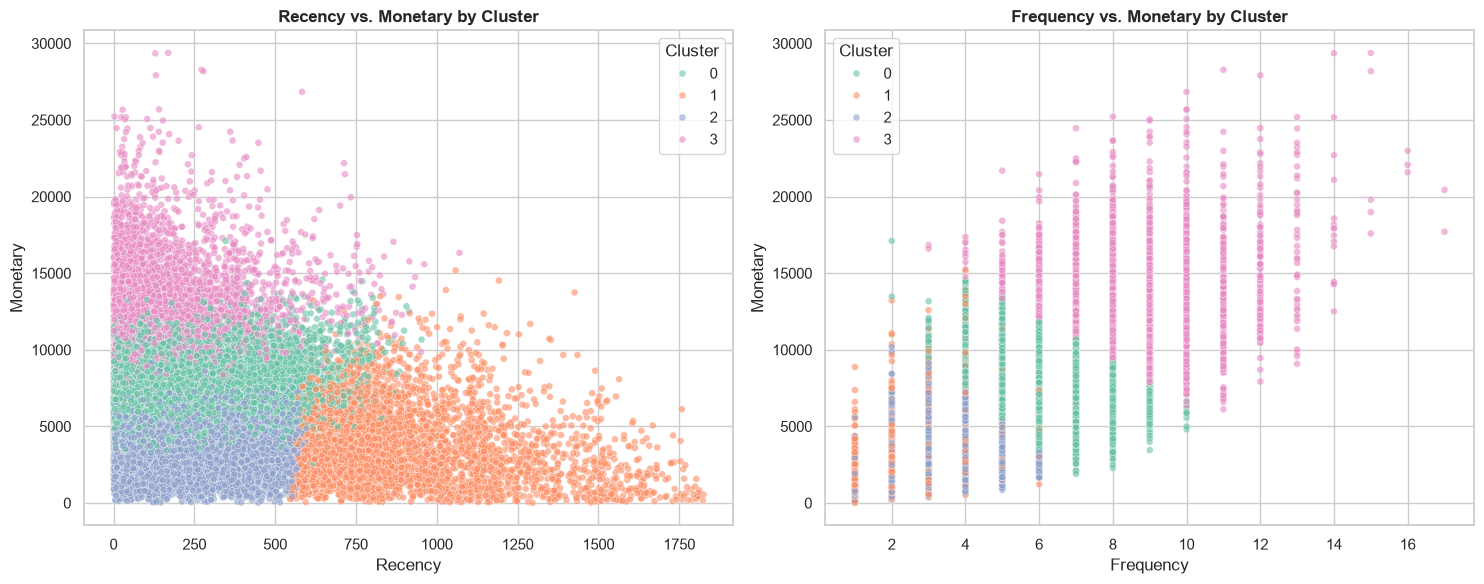

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = sns.color_palette("Set2", OPTIMAL_K)

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette=palette,
                 s=25, alpha=0.6, ax=axes[0])
axes[0].set_title("Recency vs. Monetary by Cluster", fontweight="bold")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette=palette,
                 s=25, alpha=0.6, ax=axes[1])
axes[1].set_title("Frequency vs. Monetary by Cluster", fontweight="bold")

plt.tight_layout()
plt.show()

**Observation:** Unlike a synthetic dataset engineered for clean separation, real behavioural
data shows visible density overlap at cluster edges — expected and realistic. Even so, the
Recency-vs-Monetary view clearly separates a low-recency, high-monetary group (recently active,
high-spending) from a high-recency, low-monetary group (long-dormant, low historical spend). The
Frequency-vs-Monetary view shows Monetary doing more of the separating work than Frequency alone —
consistent with Section 3's finding that spend is more right-skewed (and therefore more
cluster-defining) than order count.

## 8. Cluster Profiling

In [13]:
cluster_profile = rfm.groupby("Cluster")[features].mean().round(1)
cluster_profile["Customer Count"] = rfm["Cluster"].value_counts().sort_index()
cluster_profile = cluster_profile.sort_values("Monetary", ascending=False)
cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
3,163.7,8.5,13012.6,3968
0,217.8,6.1,7630.4,9179
1,914.4,3.1,3809.9,3880
2,233.6,3.6,3735.7,7849


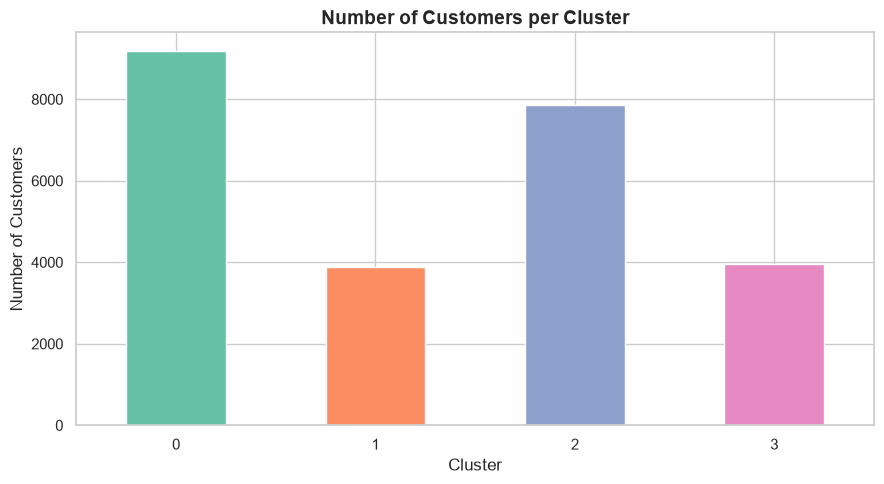

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
rfm["Cluster"].value_counts().sort_index().plot(kind="bar", ax=ax, color=sns.color_palette("Set2", OPTIMAL_K))
ax.set_title("Number of Customers per Cluster", fontsize=14, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Observation — the four segments that emerged:**

- **Champions** (Recency ≈164 days, Frequency ≈8.5 orders, Monetary ≈\$13,013, **3,968 customers /
  16%**): the smallest cluster but by far the highest value — order almost 3x as often as the lowest
  segment and spend over 3x as much.
- **Loyal / Core Customers** (Recency ≈218 days, Frequency ≈6.1, Monetary ≈\$7,630, **9,179
  customers / 37%, the largest segment**): solid, dependable mid-tier behaviour — this is the revenue
  backbone of the business by sheer size.
- **Low-Engagement** (Recency ≈234 days, Frequency ≈3.6, Monetary ≈\$3,736, **7,849 customers /
  32%**): ordered fairly recently (similar recency to the Loyal group) but at much lower frequency and
  spend — never became deeply engaged despite being active.
- **Deeply Lapsed** (Recency ≈914 days — **over 2.5 years** since last order, Frequency ≈3.1, Monetary
  ≈\$3,810, **3,880 customers / 16%**): essentially churned. Notably, their historical Frequency/
  Monetary is nearly identical to the Low-Engagement group — the defining difference is entirely
  Recency, meaning these customers didn't necessarily spend less per relationship, they simply stopped
  coming back.

## 9. Insights & Marketing Recommendations

**By segment:**

1. **Champions (3,968 customers, 16%, ≈\$13,013 avg. spend):** Protect this relationship with a
   VIP/loyalty tier — early access, exclusive perks, a dedicated support line. Avoid discounting to this
   group; they already convert at full value, so a loyalty *reward* preserves margin while reinforcing
   retention. This is a small slice of the customer base but a disproportionately large share of value —
   losing even a few of these customers has an outsized revenue impact.

2. **Loyal / Core Customers (9,179 customers, 37% — the largest segment, ≈\$7,630 avg. spend):** Use
   cross-sell and upsell campaigns — personalized recommendations based on order history — to nudge
   frequency and spend upward toward Champion-level behaviour. Because this is the single largest
   segment by count, even a modest per-customer lift (say, one extra order per year) compounds into the
   largest absolute revenue gain of any single action across all four segments.

3. **Deeply Lapsed (3,880 customers, 16%, dormant ~2.5 years, ≈\$3,810 historical spend):** This is the
   highest-priority **win-back** target — not because their historical spend was high, but because the
   segment is defined almost entirely by *time since last order* rather than low value, meaning
   reactivation is plausible with the right nudge (time-limited discount, "we miss you" email
   referencing past purchases) rather than requiring a fundamentally different offer.

4. **Low-Engagement (7,849 customers, 32%, active but low spend, ≈\$3,736 avg. spend):** Since this
   group is *not* dormant (similar recency to the Loyal segment) but simply never engaged deeply, focus
   on **increasing basket size and frequency** rather than reactivation — small order-frequency
   incentives, bundling, or the delivery-speed lever confirmed in Task 1 (faster delivery correlated
   strongly with higher ratings, which plausibly converts occasional buyers into repeat ones).

**General note:** cluster boundaries here are specific to this customer base's own R/F/M distribution
(scaled via `StandardScaler`) — don't apply raw dollar or day thresholds from other businesses or
datasets when reusing this approach elsewhere.